In [1]:
using CSV
using DataFrames
using FFTW
using Plots
using DelimitedFiles
using LinearAlgebra

In [2]:
function coordinates_to_angle(x1,y1,x2,y2)
    return atan(y2-y1,x2-x1)
end

coordinates_to_angle (generic function with 1 method)

In [3]:
coordinates_to_angle(0,0,1,-1)

-0.7853981633974483

In [4]:
# Define the grid dimensions and ranges
n = 800  # number of points along each axis
x_range = range(-10, 10, length=n)
y_range = range(-10, 10, length=n)

lambdaF = 1;
p_F = 2*pi/lambdaF;

## The two impurities are at (a,0) and (-a,0)
a = 5*lambdaF;
r12 = 2*a;

In [5]:
custom_cmap = cgrad([:blue, :white, :orange], [0.4, 0.6])

In [6]:
function phi(r)
    return p_F*r - pi/4
end

phi (generic function with 1 method)

In [7]:
# Initialize the data container
results_2nd_order = DataFrame(x=Float64[], y=Float64[], value=Float64[])
results_2nd_order_hyperbola = DataFrame(x=Float64[], y=Float64[], value=Float64[])
results_1st_order = DataFrame(x=Float64[], y=Float64[], value=Float64[])
results_1st_order_one_impurity = DataFrame(x=Float64[], y=Float64[], value=Float64[])

Delta = 1;
omega0 = 1.1*Delta;

vF=1000;
theta12 = 0;

# dV = 0.01

In [8]:
sigma_x = [0 1; 1 0]
sigma_y = [0 -im; im 0]
sigma_z = [1 0; 0 -1]
sigma_plus = [0 1; 0 0]
sigma_minus = [0 0; 1 0];
sigma_zero = [1 0; 0 1];
sigma_prefactor = (sigma_zero + sigma_z)/2;

In [9]:
function Green_function(x1,x2,y1,y2, omega)
    dist = sqrt((x1-x2)^2 + (y1-y2)^2)

    g_plus = exp(im*phi(dist)) * exp(im*sqrt(omega^2 - Delta^2)*dist/vF) * ((im*omega/sqrt(omega^2 - Delta^2))*sigma_zero + im*sigma_z + ((sigma_plus)*im*Delta*exp(2*im*coordinates_to_angle(x1,y1,x2,y2)) + (sigma_minus)*im*Delta*exp(-2*im*coordinates_to_angle(x1,y1,x2,y2)))/sqrt(omega^2 - Delta^2))
    g_minus = exp(-im*phi(dist)) * exp(im*sqrt(omega^2 - Delta^2)*dist/vF) * ((im*omega/sqrt(omega^2 - Delta^2))*sigma_zero - im*sigma_z + ((sigma_plus)*im*Delta*exp(2*im*coordinates_to_angle(x1,y1,x2,y2)) + (sigma_minus)*im*Delta*exp(-2*im*coordinates_to_angle(x1,y1,x2,y2)))/sqrt(omega^2 - Delta^2))

    return g_plus/sqrt(sqrt(dist^2+lambdaF^2)), g_minus/sqrt(sqrt(dist^2+lambdaF^2))
end

Green_function (generic function with 1 method)

In [10]:
G12_plus, G12_minus = Green_function(a,-a,0,0,omega0)
G12 = G12_plus + G12_minus

2×2 Matrix{ComplexF64}:
    0.441191+1.07286im   -0.00446101+0.973465im
 -0.00446101+0.973465im    -0.451005+1.06877im

In [12]:
for x in x_range, y in y_range

    G30_plus, G30_minus = Green_function(x,0,y,0,omega0)

    G30 = G30_plus + G30_minus

    value_1st_order_one_imp = 100*(-1/(2*pi)) * imag(tr((G30*sigma_z*G30)))

    push!(results_1st_order_one_impurity, (x, y, value_1st_order_one_imp))
end

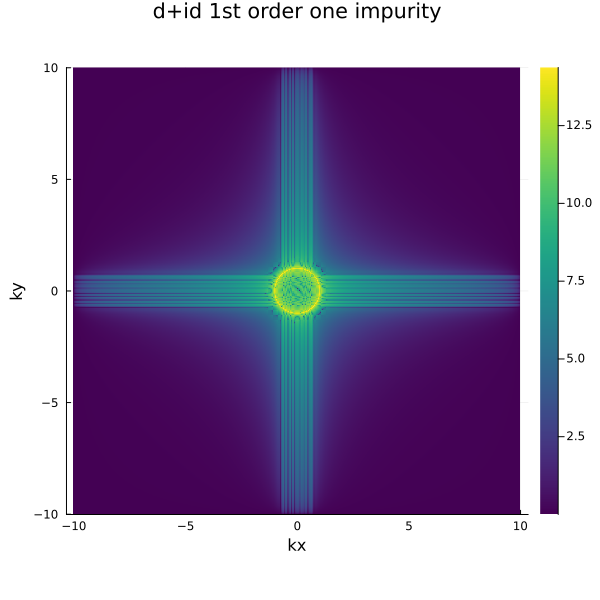

In [13]:
# Extract columns
x = results_1st_order_one_impurity.x
y = results_1st_order_one_impurity.y
data_1st_order_one_impurity = results_1st_order_one_impurity.value

# Get unique x and y values
unique_x = unique(x)
unique_y = unique(y)

# Reshape data into a 2D array
data_1st_order_one_impurity_reshaped = reshape(data_1st_order_one_impurity, length(unique_y), length(unique_x))

# Step 2: Perform 2D Fourier Transform
ft_data_one_impurity = fft(data_1st_order_one_impurity_reshaped)
ft_data_shifted_one_impurity = fftshift(ft_data_one_impurity)

# Compute magnitude and log scale for better visualization
ft_magnitude_one_impurity = abs.(ft_data_shifted_one_impurity)
ft_magnitude_log_one_impurity = log1p.(ft_magnitude_one_impurity)  # log(1 + magnitude) for stability

# Step 3: Plot the Fourier Transform
heatmap(
    unique_x, unique_y, ft_magnitude_log_one_impurity,
    color=:viridis, aspect_ratio=:equal,
    xlabel="kx", ylabel="ky",
    title="d+id 1st order one impurity",
    # framestyle=:none, 
    size=(600, 600)
)

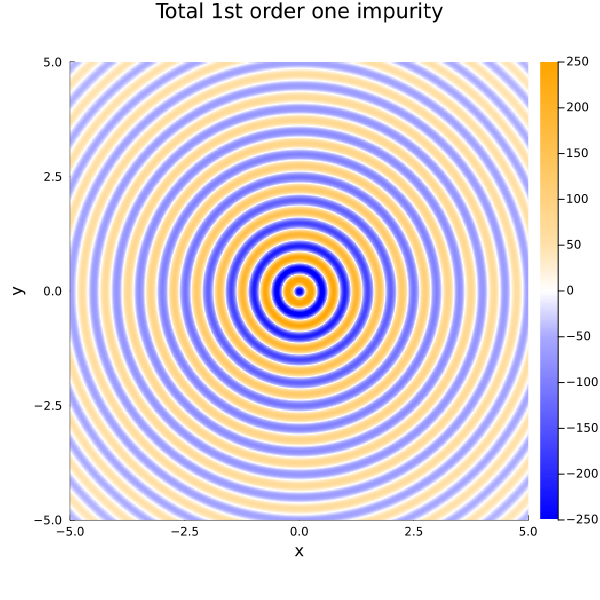

In [18]:
p_total_first_order_one_imp= heatmap(
    unique_x, unique_y,  data_1st_order_one_impurity_reshaped,
    color=custom_cmap, aspect_ratio=:equal,
    xlim=(-5, 5), ylim=(-5, 5),
    xlabel="x", ylabel="y",
    clim=(-250,250),
    title="Total 1st order one impurity",
    size=(600, 600)
)